In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

In [50]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [51]:
df = pd.read_csv("G:/task-2/Reviews.csv")
df = df[['Score', 'Text']]
df.columns = ['rating', 'review']

In [52]:
print("\nDataset Shape:")
df.shape


Dataset Shape:


(568454, 2)

In [53]:
print(df.columns)

Index(['rating', 'review'], dtype='str')


In [54]:
df.rename(columns={'Score': 'rating'}, inplace=True)

df['sentiment'] = df['rating'].apply(
    lambda x: 'Positive' if x >= 4 else ('Neutral' if x == 3 else 'Negative')
)

In [55]:
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,rating,review,sentiment
0,5,I have bought several of the Vitality canned d...,Positive
1,1,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,This is a confection that has been around a fe...,Positive
3,2,If you are looking for the secret ingredient i...,Negative
4,5,Great taffy at a great price. There was a wid...,Positive


In [56]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


rating       0
review       0
sentiment    0
dtype: int64

In [57]:
df.dropna(inplace=True)

In [58]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
df['sentiment'] = df['rating'].apply(sentiment_label)

C:\Users\user\AppData\Local\Temp\ipykernel_14612\380132659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sentiment'],palette='viridis')


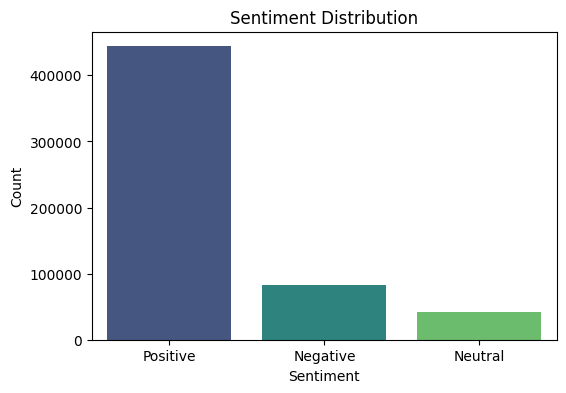

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'],palette='viridis')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [60]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(cleaned_words)

In [61]:
df = df.sample(50000, random_state=42)
df['cleaned_review'] = df['review'].astype(str).apply(clean_text)

In [62]:
X = df['cleaned_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
tfidf = TfidfVectorizer(max_features=2000,stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Train Shape:", X_train_tfidf.shape)
print("Test Shape:", X_test_tfidf.shape)

Train Shape: (40000, 2000)
Test Shape: (10000, 2000)


In [ ]:
lr_model = LogisticRegression(max_iter=500) 
lr_model.fit(X_train_tfidf, y_train) 
nb_model = MultinomialNB() 
nb_model.fit(X_train_tfidf, y_train) 
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_tfidf, y_train)

In [20]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"{model_name} PERFORMANCE")
    print(f"{'='*60}")
    print(f"\nAccuracy Score: {accuracy:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression PERFORMANCE

Accuracy Score: 0.8498

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65      1421
     Neutral       0.45      0.09      0.15       758
    Positive       0.87      0.97      0.92      7821

    accuracy                           0.85     10000
   macro avg       0.68      0.55      0.57     10000
weighted avg       0.82      0.85      0.82     10000



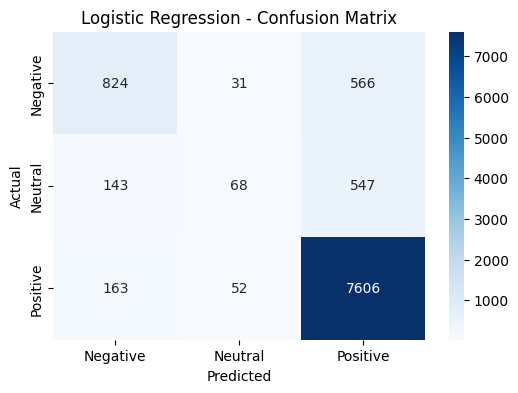


Naive Bayes PERFORMANCE

Accuracy Score: 0.8083

Classification Report:



c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

    Negative       0.88      0.20      0.32      1421
     Neutral       0.00      0.00      0.00       758
    Positive       0.81      1.00      0.89      7821

    accuracy                           0.81     10000
   macro avg       0.56      0.40      0.41     10000
weighted avg       0.76      0.81      0.74     10000



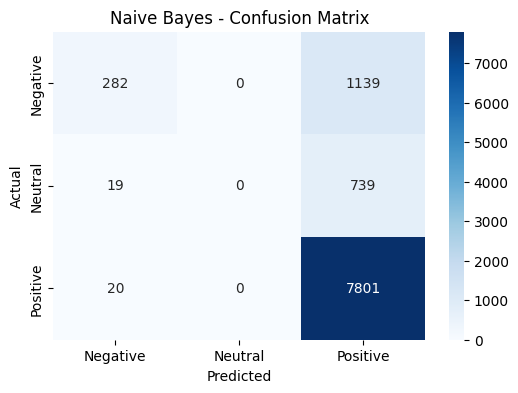


Random Forest PERFORMANCE

Accuracy Score: 0.8421

Classification Report:

              precision    recall  f1-score   support

    Negative       0.83      0.41      0.55      1421
     Neutral       0.90      0.13      0.22       758
    Positive       0.84      0.99      0.91      7821

    accuracy                           0.84     10000
   macro avg       0.86      0.51      0.56     10000
weighted avg       0.85      0.84      0.81     10000



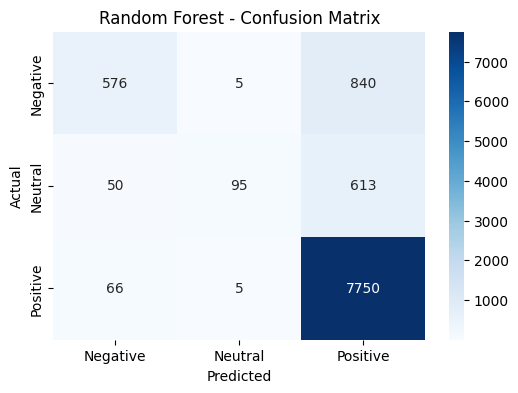

In [21]:
# ============================================================
# EVALUATE MODELS
# ============================================================
evaluate_model(lr_model,X_test_tfidf,y_test,"Logistic Regression")
evaluate_model(nb_model,X_test_tfidf,y_test,"Naive Bayes")
evaluate_model(rf_model,X_test_tfidf,y_test,"Random Forest")

In [22]:
models = {"Logistic Regression": lr_model,"Naive Bayes": nb_model,"Random Forest": rf_model}
accuracy_scores = {}
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy
accuracy_df = pd.DataFrame({"Model": accuracy_scores.keys(),"Accuracy": accuracy_scores.values()})
print("\nMODEL COMPARISON")
print(accuracy_df)


MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression    0.8498
1          Naive Bayes    0.8083
2        Random Forest    0.8421


C:\Users\user\AppData\Local\Temp\ipykernel_14612\1768203733.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()),y=list(accuracy_scores.values()),palette='magma')


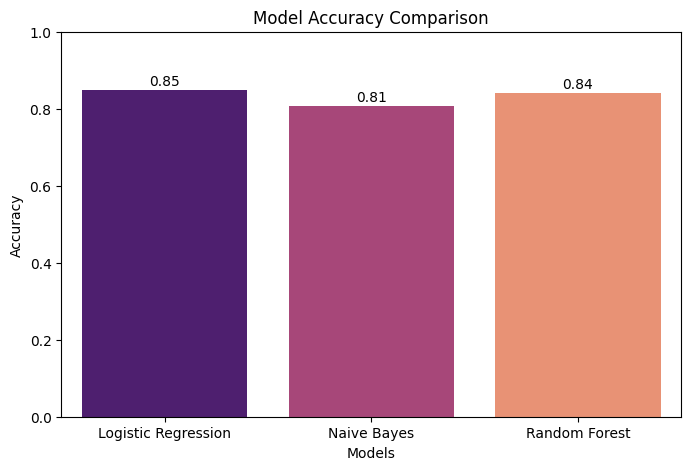

In [23]:
# ============================================================
# ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))
sns.barplot(x=list(accuracy_scores.keys()),y=list(accuracy_scores.values()),palette='magma')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
for index, value in enumerate(accuracy_scores.values()):
    plt.text(index,value + 0.01,f"{value:.2f}",ha='center')
plt.show()

In [ ]:
best_model_name = max(accuracy_scores,key=accuracy_scores.get)
best_model = models[best_model_name]
print(f"\nBest Performing Model: {best_model_name}")


Best Performing Model: Logistic Regression


In [ ]:
with open("amazon_sentiment_model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)
with open("tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(tfidf, vectorizer_file)
print("\nModel and Vectorizer Saved Successfully!")



Model and Vectorizer Saved Successfully!


In [ ]:
# ============================================================
# PREDICT NEW REVIEW SENTIMENT
# ============================================================
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    vectorized_review = tfidf.transform([cleaned_review])
    prediction = best_model.predict(vectorized_review)[0]
    return prediction


In [ ]:
sample_reviews = [
    "This product is absolutely amazing and delicious!",

    "The taste was average and packaging was okay.",

    "Worst product ever. Completely disappointed."
]
print("\nSAMPLE PREDICTIONS\n")
for review in sample_reviews:
    sentiment = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 60)

# ============================================================
# END OF PROJECT
# ============================================================


SAMPLE PREDICTIONS

Review: This product is absolutely amazing and delicious!
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The taste was average and packaging was okay.
Predicted Sentiment: Neutral
------------------------------------------------------------
Review: Worst product ever. Completely disappointed.
Predicted Sentiment: Negative
------------------------------------------------------------
